# PyTorch Basics: Tensors & Gradients

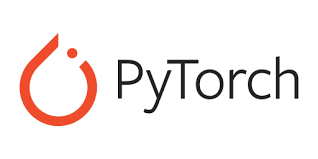



  PyTorch is an open-source machine learning framework that is primarily used for developing and training deep learning models. It was developed by Facebook's AI Research Lab and released in 2016. PyTorch provides a flexible and dynamic approach to building neural networks, making it a popular choice among researchers and developers.

The framework is built on a dynamic computational graph concept, which means that the graph is built and modified on-the-fly as the program runs. This allows for more intuitive and flexible model development, as you can use standard Python control flow statements and debug the model easily.

PyTorch supports automatic differentiation, which enables efficient computation of gradients for training neural networks using backpropagation. It provides a rich set of tools and libraries for tasks such as data loading, model building, optimization, and evaluation.

One of the key advantages of PyTorch is its support for GPU acceleration, allowing you to train models on GPUs to significantly speed up computations. It also has a large and active community, which means there are plenty of resources, tutorials, and pre-trained models available.

PyTorch is often compared to TensorFlow, another popular deep learning framework. While TensorFlow focuses more on static computation graphs, PyTorch emphasizes dynamic computation graphs. This fundamental difference in design philosophy gives PyTorch an edge when it comes to flexibility and ease of use.

Overall, PyTorch is widely used in the research community and is gaining popularity in industry applications as well. It provides a powerful and user-friendly platform for building and training deep learning models.



# Tensors in PyTorch

In [1]:
import torch

In [2]:
# Number / scalar

import torch
t1 = torch.tensor(4.)
t1

# 4. is shorthand notation  for 4.0 

tensor(4.)

In [3]:
# Vector 

t2 = torch.tensor([1., 2, 3,4])
t2

tensor([1., 2., 3., 4.])

In [4]:
# matrix 
t3 = torch.tensor([
    [5,6],
    [6,7]
    ,[7,8]
])

t3

tensor([[5, 6],
        [6, 7],
        [7, 8]])

In [5]:
# 3 dimensional array
t4 = torch.tensor([
    [
        [11, 12, 13],
        [14, 15, 16]
    ],
    [
        [17,18,19],
        [20,21,22]
    ]
])

t4

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])

In [6]:
print(t1.shape)

torch.Size([])


In [7]:
print(t2)
t2.shape

tensor([1., 2., 3., 4.])


torch.Size([4])

In [8]:
print(t3)
t3.shape

tensor([[5, 6],
        [6, 7],
        [7, 8]])


torch.Size([3, 2])

In [9]:
print(t4)
t4.shape

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])


torch.Size([2, 2, 3])

# Tensor operation and gradients 

In [10]:
# Create tensors

x = torch.tensor(3.)
w = torch.tensor(4. , requires_grad = True) # requires_grad = True means that we want to calculate the gradient of w with respect to some loss function later on.
b = torch.tensor(5., requires_grad = True)

x, w, b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

In [11]:
# Arithemitc operations

y = w*x + b
y

tensor(17., grad_fn=<AddBackward0>)

In [12]:
# compute derivatives
y.backward() # this will compute the gradients of y with respect to w and b and store them in w.grad and b.grad respectively.

In [13]:
# display the gradients
print("dy/dx : " , x.grad) # this will print the gradient of y with respect to x, which is None because we did not set requires_grad = True for x.
print("dy/dw : " , w.grad) # this will print the gradient of y with respect to w, which is 3.0 because y = 4.0 * 3.0 + 5.0 and the derivative of y with respect to w is x, which is 3.0.
print("dy/db : " , b.grad)

dy/dx :  None
dy/dw :  tensor(3.)
dy/db :  tensor(1.)


Tensor Functions 

In [14]:
# Create a tensor with a fixed value for every elemnt 

t6 = torch.full((3,2), 7) # this will create a tensor of shape (3,4) filled with the value 7.
t6

tensor([[7, 7],
        [7, 7],
        [7, 7]])

In [15]:
# concatinate two tensors with compatible  shapes
t7 = torch.cat((t3,t6))
t7

tensor([[5, 6],
        [6, 7],
        [7, 8],
        [7, 7],
        [7, 7],
        [7, 7]])

In [16]:
# change the sin of each element in a tensor
t8 = torch.sin(t7)
t8

tensor([[-0.9589, -0.2794],
        [-0.2794,  0.6570],
        [ 0.6570,  0.9894],
        [ 0.6570,  0.6570],
        [ 0.6570,  0.6570],
        [ 0.6570,  0.6570]])

In [17]:
t9 = t8.reshape(3,2,2)
t9

tensor([[[-0.9589, -0.2794],
         [-0.2794,  0.6570]],

        [[ 0.6570,  0.9894],
         [ 0.6570,  0.6570]],

        [[ 0.6570,  0.6570],
         [ 0.6570,  0.6570]]])

Interoperability with NumPy 

In [18]:
import numpy as np

x= np.array([[1,2], 
             [3,4], 
             [5,6]])
x

array([[1, 2],
       [3, 4],
       [5, 6]])

In [19]:
y = torch.from_numpy(x)
y

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [20]:
x.dtype , y.dtype 

(dtype('int64'), torch.int64)

In [21]:
z = y.numpy()
z

array([[1, 2],
       [3, 4],
       [5, 6]])

linear regression from scratch using pytorch

In [22]:
import numpy as np 
import torch 

In [23]:
# Making Training data
#  input ---> temp , rainfall , humidity ---. yield of apple and oranges crops 

inputs = np.array([
    [73,67,43],
    [91,88,64],
    [87,134,58],
    [102,43,37],
    [69,96,70],
], dtype = "float32")

In [24]:
# target (apples , oranges )

target = np.array([
    [56,70],
    [81,101],
    [119,133],
    [22,37],
    [103,119]
], dtype = "float32")   


In [25]:
# converts inputs and target to tensors

inputs = torch.from_numpy(inputs)
target = torch.from_numpy(target)

print(inputs)
print(target)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])


In [26]:
# weights and biases 

import re


w = torch.randn(2,3 , requires_grad= True)
b = torch.randn(2, requires_grad= True)

print(w)
print(b)

tensor([[ 0.2704, -2.1774, -2.4221],
        [-1.5378,  0.5680,  0.5161]], requires_grad=True)
tensor([ 0.3900, -1.1694], requires_grad=True)


In [27]:
# define the model 

# z = X* w +b

def model(x):
    return x @ w.t()+b

In [28]:
# prediction

preds = model(inputs)
preds

tensor([[-229.9070,  -53.1828],
        [-321.6289,  -58.0978],
        [-408.3364,  -28.9133],
        [-155.2776, -114.5096],
        [-359.5280,  -16.6244]], grad_fn=<AddBackward0>)

In [30]:
# loss function we will use is MSE --> mean squared error
def MSE(y,y_hat):
    diff = y - y_hat

    return torch.sum(diff*diff)/diff.numel() # this will return the mean squared error between y and y_hat.


In [31]:
# error
loss = MSE(target, preds)
loss


tensor(87534.7266, grad_fn=<DivBackward0>)

In [32]:
# compute gradients 
loss.backward()

In [33]:
print(w)
print(w.grad)

tensor([[ 0.2704, -2.1774, -2.4221],
        [-1.5378,  0.5680,  0.5161]], requires_grad=True)
tensor([[-30677.0938, -35455.1641, -21516.7988],
        [-12473.7529, -12697.0186,  -7993.9316]])


In [34]:
print(b)
print(b.grad)

tensor([ 0.3900, -1.1694], requires_grad=True)
tensor([-371.1356, -146.2656])


In [35]:
# reset grad

w.grad.zero_() # this will reset the gradients of w to zero.
b.grad.zero_() # this will reset the gradients of b to zero.

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [36]:
# Adjust params

preds = model(inputs)

print(preds)


loss = MSE(target, preds)
print(loss)

tensor([[-229.9070,  -53.1828],
        [-321.6289,  -58.0978],
        [-408.3364,  -28.9133],
        [-155.2776, -114.5096],
        [-359.5280,  -16.6244]], grad_fn=<AddBackward0>)
tensor(87534.7266, grad_fn=<DivBackward0>)


In [37]:
loss.backward()

print(w.grad)
print(b.grad)

tensor([[-30677.0938, -35455.1641, -21516.7988],
        [-12473.7529, -12697.0186,  -7993.9316]])
tensor([-371.1356, -146.2656])


In [38]:
# adjust weight & reset grad

learning_rate = 1e-5

with torch.no_grad():
  w -= w.grad * 1e-5
  b -= b.grad * 1e-5

  w.grad.zero_()
  b.grad.zero_()

In [39]:
print(w)
print(b)

tensor([[ 0.5771, -1.8228, -2.2069],
        [-1.4131,  0.6950,  0.5960]], requires_grad=True)
tensor([ 0.3937, -1.1679], requires_grad=True)


In [40]:
# Calculate again

preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(59835.9883, grad_fn=<DivBackward0>)


In [51]:
# Training for muliple epochs
for i in range(800):
  preds = model(inputs)
  loss = MSE(target, preds)
  loss.backward()
  with torch.no_grad():
    w -= w.grad * 1e-5
    b -= b.grad * 1e-5

    w.grad.zero_()
    b.grad.zero_()
  print(f"Epochs({i}/{100}) & Loss {loss}")

Epochs(0/100) & Loss 26.086496353149414
Epochs(1/100) & Loss 26.038646697998047
Epochs(2/100) & Loss 25.990985870361328
Epochs(3/100) & Loss 25.943294525146484
Epochs(4/100) & Loss 25.895763397216797
Epochs(5/100) & Loss 25.848285675048828
Epochs(6/100) & Loss 25.80086326599121
Epochs(7/100) & Loss 25.75364112854004
Epochs(8/100) & Loss 25.7064266204834
Epochs(9/100) & Loss 25.65932846069336
Epochs(10/100) & Loss 25.612314224243164
Epochs(11/100) & Loss 25.5654296875
Epochs(12/100) & Loss 25.5185546875
Epochs(13/100) & Loss 25.471813201904297
Epochs(14/100) & Loss 25.4251708984375
Epochs(15/100) & Loss 25.378589630126953
Epochs(16/100) & Loss 25.33212661743164
Epochs(17/100) & Loss 25.285707473754883
Epochs(18/100) & Loss 25.239395141601562
Epochs(19/100) & Loss 25.193195343017578
Epochs(20/100) & Loss 25.14705467224121
Epochs(21/100) & Loss 25.101016998291016
Epochs(22/100) & Loss 25.0550479888916
Epochs(23/100) & Loss 25.0091609954834
Epochs(24/100) & Loss 24.963350296020508
Epochs(2

In [52]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(6.2441, grad_fn=<DivBackward0>)


In [53]:
from math import sqrt
sqrt(loss)

2.4988188814532215

In [54]:
preds

tensor([[ 57.5177,  70.1171],
        [ 79.7718, 100.7750],
        [123.6656, 133.0250],
        [ 22.4705,  37.0491],
        [ 96.9529, 119.0722]], grad_fn=<AddBackward0>)

In [55]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])